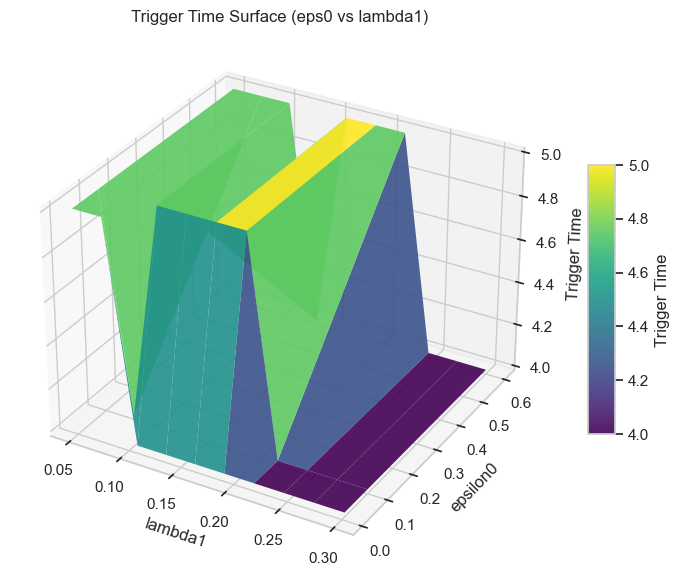

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(2025)

# ---------------------------
# Core model functions (as before)
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    N, M = len(n), R.shape[1]
    p_A = states[:,1] + states[:,2] + states[:,4]
    tilde_p = np.zeros(M)
    for j in range(M):
        flows = n * g_i * R[:, j]
        if flows.sum() > 0:
            tilde_p[j] = (flows * p_A).sum() / flows.sum()
    return tilde_p

def compute_awareness_conversion(R, lambda1, tilde_p):
    N, M = R.shape
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            prod *= (1 - lambda1 * R[i,j] * tilde_p[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    n_remain = n * (1 - g_i)
    p_I = states[:,2]
    N_U = 1 - (1 - beta_U*p_I)**n_remain
    N_A = 1 - (1 - beta_A*p_I)**n_remain
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    N, M = R.shape
    M_U = np.zeros(M); M_A = np.zeros(M)
    p_I = states[:,2]
    for j in range(M):
        prod_U, prod_A = 1.0, 1.0
        for k in range(N):
            flow = n[k] * g_i[k] * R[k,j]
            prod_U *= (1 - beta_U*p_I[k])**flow
            prod_A *= (1 - beta_A*p_I[k])**flow
        M_U[j] = 1 - prod_U
        M_A[j] = 1 - prod_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    N = len(n)
    Q_U = np.zeros(N); Q_A = np.zeros(N)
    for i in range(N):
        Q_U[i] = (1-g_i[i])*N_U[i] + g_i[i] * np.dot(R[i], M_U)
        Q_A[i] = (1-g_i[i])*N_A[i] + g_i[i] * np.dot(R[i], M_A)
    return Q_U, Q_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    US, AS, AI, UR, AR = [states[:, i] for i in range(5)]
    new = np.zeros_like(states)
    new[:,0] = US*(1-r)*(1-Q_U) + AS*mu1*(1-Q_U)
    new[:,1] = AS*(1-mu1)*(1-Q_A) + US*r*(1-Q_A)
    new[:,2] = AI*(1-mu2) + AS*(1-mu1)*Q_A + AS*mu1*Q_U + US*(1-r)*Q_U + US*r*Q_A
    new[:,3] = AI*mu1*mu2 + AR*mu1 + UR*(1-r)
    new[:,4] = AR*(1-mu1) + AI*(1-mu1)*mu2 + UR*r
    new /= np.clip(new.sum(axis=1, keepdims=True), 1e-10, None)
    return new

def update_population(n, states, g_i, epsilon, R, T):
    X = states * n[:,None]
    F = n * g_i * epsilon
    X_remain = X - (X.T * (g_i*epsilon)).T
    n_remain = n - F

    M = R.shape[1]
    m = np.zeros(M); m_X = np.zeros((M,5))
    for j in range(M):
        flows = n * g_i * epsilon * R[:,j]
        m[j] = flows.sum()
        m_X[j] = (X * (g_i*epsilon)[:,None] * R[:,j][:,None]).sum(axis=0)

    flow_return = np.zeros_like(n, dtype=float)
    flow_return_X = np.zeros_like(X, dtype=float)
    for j in range(M):
        flow_return += m[j] * T[:,j]
        flow_return_X += np.outer(T[:,j], m_X[j])

    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:,None], 1e-10, None)
    return n_new, new_states

def simulate(Time, N, M, params):
    lambda1, mu1, mu2 = params['lambda1'], params['mu1'], params['mu2']
    beta_U, beta_A = params['beta_U'], params['beta_A']
    g_i = np.full(N, params['theta']*params['g'])
    n = np.arange(100, 100+50*N, 50, dtype=int)
    states = np.zeros((N,5))
    states[:,0]=0.99; states[:,2]=0.01
    states /= states.sum(axis=1,keepdims=True)
    w = np.random.rand(N,M)
    R = w/w.sum(axis=1,keepdims=True)
    T = w/w.sum(axis=0,keepdims=True)

    ai = []
    trigger_time = None

    for t in range(Time):
        epsilon = compute_epsilon(states, params['alpha'], params['epsilon0'])
        if trigger_time is None and np.any(epsilon>0):
            trigger_time = t
        n, states = update_population(n, states, g_i, epsilon, R, T)
        tilde = compute_effective_awareness(n, states, g_i, R)
        r = compute_awareness_conversion(R, lambda1, tilde)
        N_U, N_A = compute_infection_residence(n, states, g_i, beta_U, beta_A)
        M_U, M_A = compute_infection_transit(n, states, g_i, R, beta_U, beta_A)
        Q_U, Q_A = compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A)
        states = update_states(states, r, Q_U, Q_A, mu1, mu2)
        total = (states * n[:,None]).sum(axis=0)
        ai.append(total[2]/n.sum())

    if trigger_time is None:
        trigger_time = Time
    if 5 < trigger_time < Time-5:
        pre_slope = (ai[trigger_time] - ai[trigger_time-5]) / 5
        post_slope = (ai[trigger_time+5] - ai[trigger_time]) / 5
        slope_change = post_slope - pre_slope
    else:
        slope_change = 0.0

    return trigger_time, max(ai), slope_change

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import warnings
# 忽略FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

# 参数网格
epsilon_list = np.array([0.01, 0.1, 0.6])
lambda_list = np.linspace(0.05, 0.3, 10)
Time, N, M = 140, 15, 5

# 固定参数
base_params = {
    'mu1': 0.15, 'mu2': 0.2,
    'beta_U': 0.003, 'beta_A': 0.0015,
    'g': 0.5, 'theta': 1,
    'alpha': 0.3
}

# 网格存储触发时间
trigger_grid = np.zeros((len(epsilon_list), len(lambda_list)))

# 计算
for i, eps in enumerate(epsilon_list):
    for j, lam in enumerate(lambda_list):
        params = base_params.copy()
        params.update({'epsilon0': eps, 'lambda1': lam})
        trigger_grid[i, j] = simulate(Time, N, M, params)[0]  # 返回 (trigger, peak, slope)

# 使用 Seaborn 风格
sns.set_theme(style="whitegrid")

# 3D 绘图
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 创建网格
L, E = np.meshgrid(lambda_list, epsilon_list)
# 绘制曲面
surf = ax.plot_surface(L, E, trigger_grid, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('lambda1')
ax.set_ylabel('epsilon0')
ax.set_zlabel('Trigger Time')
ax.set_title('Trigger Time Surface (eps0 vs lambda1)')
fig.colorbar(surf, shrink=0.5, aspect=10, label='Trigger Time')

plt.show()
